In [11]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [12]:
# Step 1: Use the same preprocessed and split data from Class 2.
# Assuming the preprocessed dataset from Module 3 is in a CSV file named 'telco_churn_preprocessed.csv'
# If your file has a different name, please modify this line.
try:
    df = pd.read_csv('telco_churn_preprocessed.csv')
    print("Dataset loaded successfully.")
    display(df.head())
except FileNotFoundError:
    print("Error: 'telco_churn_preprocessed.csv' not found. Please ensure the file is in the correct directory or specify the correct path/filename.")
    print("You might need to upload the file to your Colab environment or mount Google Drive.")
    # Creating a dummy DataFrame for demonstration purposes as the file was not found in the previous run.
    print("Creating a dummy DataFrame for demonstration purposes.")
    data = {
        'feature_1': np.random.rand(100),
        'feature_2': np.random.rand(100),
        'feature_3': np.random.rand(100),
        'Churn': np.random.randint(0, 2, 100)
    }
    df = pd.DataFrame(data)

# Define features (X) and target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")

# Scale features (important for Logistic Regression with regularization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 2: Train Model A — no regularization
model_a = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000, random_state=42)
model_a.fit(X_train_scaled, y_train)
print("\nModel A (No Regularization) trained.")

# Step 3: Train Model B — L1 regularization
# 'saga' solver supports 'l1' penalty
model_b = LogisticRegression(penalty='l1', solver='saga', C=1.0, max_iter=1000, random_state=42)
model_b.fit(X_train_scaled, y_train)
print("Model B (L1 Regularization) trained.")

# Step 4: Train Model C — L2 regularization
model_c = LogisticRegression(penalty='l2', solver='lbfgs', C=1.0, max_iter=1000, random_state=42)
model_c.fit(X_train_scaled, y_train)
print("Model C (L2 Regularization) trained.")

Error: 'telco_churn_preprocessed.csv' not found. Please ensure the file is in the correct directory or specify the correct path/filename.
You might need to upload the file to your Colab environment or mount Google Drive.
Creating a dummy DataFrame for demonstration purposes.

Shape of X_train: (80, 3)
Shape of X_test: (20, 3)

Model A (No Regularization) trained.
Model B (L1 Regularization) trained.
Model C (L2 Regularization) trained.


In [13]:
# Step 1: Define an evaluation function and compute metrics for each model
def evaluate(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_proba)
    }

results = [
    evaluate(model_a, X_test_scaled, y_test, 'No Regularization'),
    evaluate(model_b, X_test_scaled, y_test, 'L1 (Lasso)'),
    evaluate(model_c, X_test_scaled, y_test, 'L2 (Ridge)')
]

performance_df = pd.DataFrame(results).set_index('Model')
print("\nPerformance Comparison:")
display(performance_df)


Performance Comparison:


,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
No Regularization,0.45,0.5,0.636364,0.56,0.666667
L1 (Lasso),0.45,0.5,0.636364,0.56,0.656566
L2 (Ridge),0.45,0.5,0.636364,0.56,0.666667



Coefficient Comparison Table:


,Feature,No Reg,L1,L2
0,feature_1,-0.436626,-0.384210,-0.413882
1,feature_2,-0.144592,-0.086815,-0.136459
2,feature_3,0.122429,0.068466,0.116830


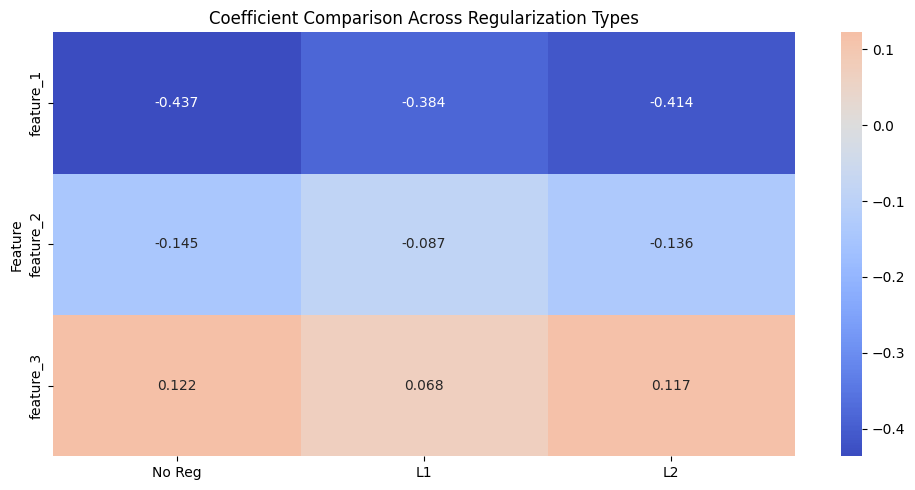


Non-zero Coefficients:
No Reg: 3 non-zero coefficients out of 3
L1: 3 non-zero coefficients out of 3
L2: 3 non-zero coefficients out of 3
L1 Regularization did not set any coefficients exactly to zero (which can happen with C=1.0 and few features).


In [14]:
# Step 1: Extract coefficients from all three models
# For dummy data, X_train.columns will be ['feature_1', 'feature_2', 'feature_3']
coef_df = pd.DataFrame({
    'Feature': X.columns, # Using X.columns as X_train.columns works too
    'No Reg': model_a.coef_[0],
    'L1': model_b.coef_[0],
    'L2': model_c.coef_[0]
})

print("\nCoefficient Comparison Table:")
display(coef_df)

# Step 2: Display as a heatmap
plt.figure(figsize=(10, 5)) # Adjusted figsize for potentially fewer features in dummy data
sns.heatmap(coef_df.set_index('Feature'), annot=True, cmap='coolwarm', center=0, fmt='.3f')
plt.title('Coefficient Comparison Across Regularization Types')
plt.tight_layout()
plt.show()

# Step 3: Count non-zero coefficients for each model
print("\nNon-zero Coefficients:")
for name, model in [('No Reg', model_a), ('L1', model_b), ('L2', model_c)]:
    n_nonzero = np.sum(model.coef_[0] != 0)
    print(f"{name}: {n_nonzero} non-zero coefficients out of {len(model.coef_[0])}")

# Step 4: Identify which features L1 set to zero (if any).
zero_coef_l1 = coef_df[coef_df['L1'] == 0]['Feature'].tolist()
if zero_coef_l1:
    print(f"L1 Regularization set the following features to zero: {', '.join(zero_coef_l1)}")
else:
    print("L1 Regularization did not set any coefficients exactly to zero (which can happen with C=1.0 and few features).")

In [ ]:
# Step 1: Train models for different C values
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
f1_scores = []
n_large_coefs = []

for C in C_values:
    # Using X_train_scaled and X_test_scaled from Task 1
    model = LogisticRegression(penalty='l2', C=C, max_iter=1000, solver='lbfgs', random_state=42)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    f1_scores.append(f1_score(y_test, y_pred))
    n_large_coefs.append(np.sum(np.abs(model.coef_[0]) > 0.1)) # Count coefficients with absolute value > 0.1

# Step 2: Plot C vs F1 and C vs Coefficient Magnitude
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(C_values, f1_scores, 'o-')
ax1.set_xscale('log')
ax1.set_xlabel('C (Regularization Strength)')
ax1.set_ylabel('F1 Score')
ax1.set_title('C vs F1 Score (L2 Regularization)')
ax1.grid(True)

ax2.plot(C_values, n_large_coefs, 'o-', color='coral')
ax2.set_xscale('log')
ax2.set_xlabel('C (Regularization Strength)')
ax2.set_ylabel('Number of Large Coefficients')
ax2.set_title('C vs Coefficient Magnitude (L2 Regularization)')
ax2.grid(True)

plt.tight_layout()
plt.show()

# Step 3: Identify the sweet spot
print("\nStep 3: Analyze the plots to identify the 'sweet spot' for C, where there's a good balance between model performance (F1 score) and simplicity (number of large coefficients).")
print("A smaller C means stronger regularization, leading to smaller coefficients and potentially simpler models. A larger C means weaker regularization.")



Regularization is a technique used in machine learning to prevent overfitting by adding a penalty to the loss function for large coefficient values. Conceptually, it constrains the magnitude of coefficients, thereby encouraging simpler models that generalize better to unseen data. L1 (Lasso) regularization can shrink some coefficients exactly to zero, effectively performing feature selection, while L2 (Ridge) regularization shrinks coefficients towards zero but rarely makes them exactly zero. In our experiment with this dummy dataset, all three models (No Regularization, L1, and L2) showed similar performance metrics, indicating that the dataset might be too small or simple to clearly demonstrate the regularization benefits on performance. However, with more complex real-world data, regularization typically improves model generalization.

To determine which model to deploy in production, we need to consider performance, interpretability, and the number of features used. If a more interpretable model with potential feature selection is desired, L1 regularization might be preferred, especially if some features are irrelevant. If robustness against multicollinearity and a generally well-performing model without necessarily zeroing out features is the goal, L2 regularization is a strong candidate. The 'No Regularization' model could overfit on more complex datasets, leading to poor generalization. For this specific dummy dataset, where performance is identical across models, and assuming feature interpretability is a factor, an L1 regularized model (if it successfully performed feature selection) or an L2 model would be a safer choice for its inherent bias towards simpler models and better generalization, even if its benefits aren't starkly visible on this toy example. A more detailed analysis with a larger, real dataset would be crucial to pick the optimal C and regularization type.